# 04 — MMR parameter analysis

## Goal

So sánh tắt/bật MMR và lambda theo Precision, F1 và redundancy.

## Setup

Khởi tạo đường dẫn, module thuật toán và thư mục artifact.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').is_dir():
    for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
        if (candidate / 'data' / 'DUC_TEXT').is_dir():
            PROJECT_ROOT = candidate
            break

NOTEBOOK_DIR = PROJECT_ROOT / 'notebooks' / 'textrank-parameter-analysis'
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from experiment_utils import *

TRAIN_DIR = PROJECT_ROOT / 'data' / 'DUC_TEXT' / 'train'
TEST_DIR = PROJECT_ROOT / 'data' / 'DUC_TEXT' / 'test'
REFERENCE_DIR = PROJECT_ROOT / 'data' / 'DUC_SUM'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'output' / 'textrank-parameter-analysis'
CSV_DIR = OUTPUT_DIR / 'csv'
CHART_DIR = OUTPUT_DIR / 'charts'
CSV_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
print(f'Project: {PROJECT_ROOT}')
print(f'Output : {OUTPUT_DIR}')

Project: /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice
Output : /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice/data/output/textrank-parameter-analysis


## Steps

### 1. Load train-selected threshold and PageRank

In [2]:
threshold_row = rank_configurations(read_csv(CSV_DIR / '02-threshold-summary.csv'), 50)[0]
pagerank_row = rank_configurations(read_csv(CSV_DIR / '03-pagerank-summary.csv'), 50)[0]
base = config_from_row(pagerank_row)
print('Base config:', config_id(base))

Base config: t=0.02|d=0.85|tol=1e-08|iter=1000|words=100|mmr=0.70


### 2. Sweep MMR

In [3]:
MMR_LAMBDAS = [0.30, 0.50, 0.70, 0.90, 1.00]
configs = [TextRankConfig(base.similarity_threshold, base.pagerank_damping,
                          base.pagerank_tolerance, base.pagerank_max_iterations,
                          100, False, 0.0)]
configs += [TextRankConfig(base.similarity_threshold, base.pagerank_damping,
                           base.pagerank_tolerance, base.pagerank_max_iterations,
                           100, True, value) for value in MMR_LAMBDAS]
mmr_details, mmr_summaries = run_sweep(TRAIN_DIR, REFERENCE_DIR, configs, 'train')
ranked_mmr = rank_configurations(mmr_summaries, required_topics=50)
write_csv(CSV_DIR / '04-mmr-topic-metrics.csv', mmr_details, DETAIL_FIELDS)
write_csv(CSV_DIR / '04-mmr-summary.csv', ranked_mmr, SUMMARY_FIELDS)
best_mmr_row = ranked_mmr[0]
print('Best MMR option:', best_mmr_row['config_id'])

Best MMR option: t=0.02|d=0.85|tol=1e-08|iter=1000|words=100|mmr=0.70


### 3. Plot quality and redundancy

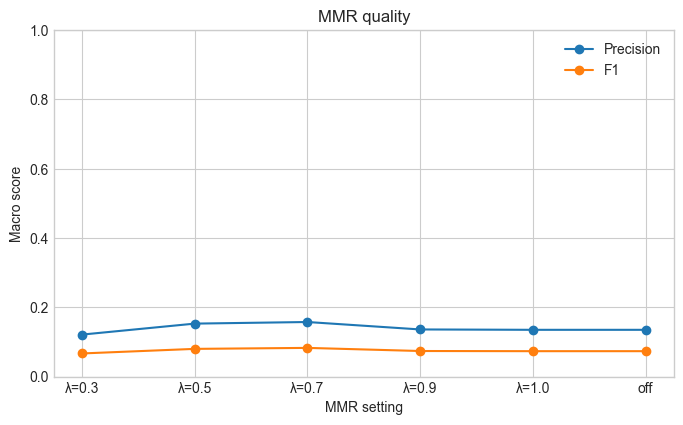

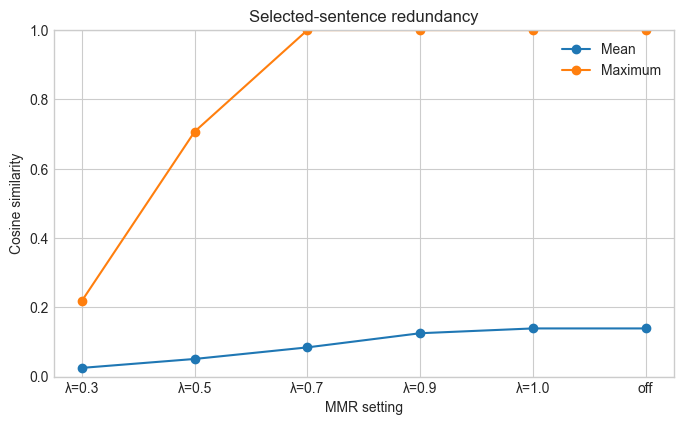

In [4]:
ordered = sorted(mmr_summaries, key=lambda row: (-int(bool(row['use_mmr'])), row['mmr_lambda'] or -1))
labels = ['off' if not row['use_mmr'] else f"λ={row['mmr_lambda']:.1f}" for row in ordered]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(labels, [row['macro_precision'] for row in ordered], marker='o', label='Precision')
ax.plot(labels, [row['macro_f1'] for row in ordered], marker='o', label='F1')
ax.set(title='MMR quality', xlabel='MMR setting', ylabel='Macro score', ylim=(0, 1))
ax.legend()
fig.savefig(CHART_DIR / '04-mmr-quality.png', dpi=160, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(labels, [row['mean_redundancy'] for row in ordered], marker='o', label='Mean')
ax.plot(labels, [row['max_redundancy'] for row in ordered], marker='o', label='Maximum')
ax.set(title='Selected-sentence redundancy', xlabel='MMR setting', ylabel='Cosine similarity', ylim=(0, 1))
ax.legend()
fig.savefig(CHART_DIR / '04-mmr-redundancy.png', dpi=160, bbox_inches='tight')
plt.show()

## Checks

Các assertion dưới đây bảo đảm artifact và dữ liệu của notebook đầy đủ.

In [5]:
assert len(mmr_summaries) == 6
assert sum(not row['use_mmr'] for row in mmr_summaries) == 1
for path in [CSV_DIR / '04-mmr-summary.csv', CSV_DIR / '04-mmr-topic-metrics.csv',
             CHART_DIR / '04-mmr-quality.png', CHART_DIR / '04-mmr-redundancy.png']:
    assert path.is_file() and path.stat().st_size > 0, path
print('All MMR checks passed.')

All MMR checks passed.


## Takeaways

In [6]:
label = 'off' if not best_mmr_row['use_mmr'] else f"lambda={best_mmr_row['mmr_lambda']}"
print(f"Best tested MMR setting={label}, Precision={float(best_mmr_row['macro_precision']):.4f}, "
      f"F1={float(best_mmr_row['macro_f1']):.4f}, "
      f"mean redundancy={float(best_mmr_row['mean_redundancy']):.4f}.")

Best tested MMR setting=lambda=0.7, Precision=0.1575, F1=0.0828, mean redundancy=0.0843.
